In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
import pandas as pd

# Your actual warm region is 'Sud'
WARM_REGIONS = ['Sud']

# Load original data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

print(f"Original: {len(df_quotes):,} quotes")

# Filter to warm regions
df_quotes = df_quotes[df_quotes['nom_region'].isin(WARM_REGIONS)]

print(f"Warm: {len(df_quotes):,} quotes, {df_quotes['numero_compte'].nunique():,} customers")

# Save
df_quotes.to_csv('cleaned_quote_data_warm.csv', index=False)
print("✅ Saved to cleaned_quote_data_warm.csv")

Original: 37,008 quotes
Warm: 889 quotes, 644 customers
✅ Saved to cleaned_quote_data_warm.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_warm.csv')


📊 Original quote data: 889 quotes from 644 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 644, Quotes: 868
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 644 customers | 31.4% converters
⏱️  Execution time: 0.3 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 889
  Total customers: 644
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 644
    Quotes after filter: 871
⚡ Processing 644 customers with sequence features...

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 644
  Converters: 202 (31.4%)
  Features created: 21
  Product column used: regroup_famille_equipement_produit_principal
  Execution tim

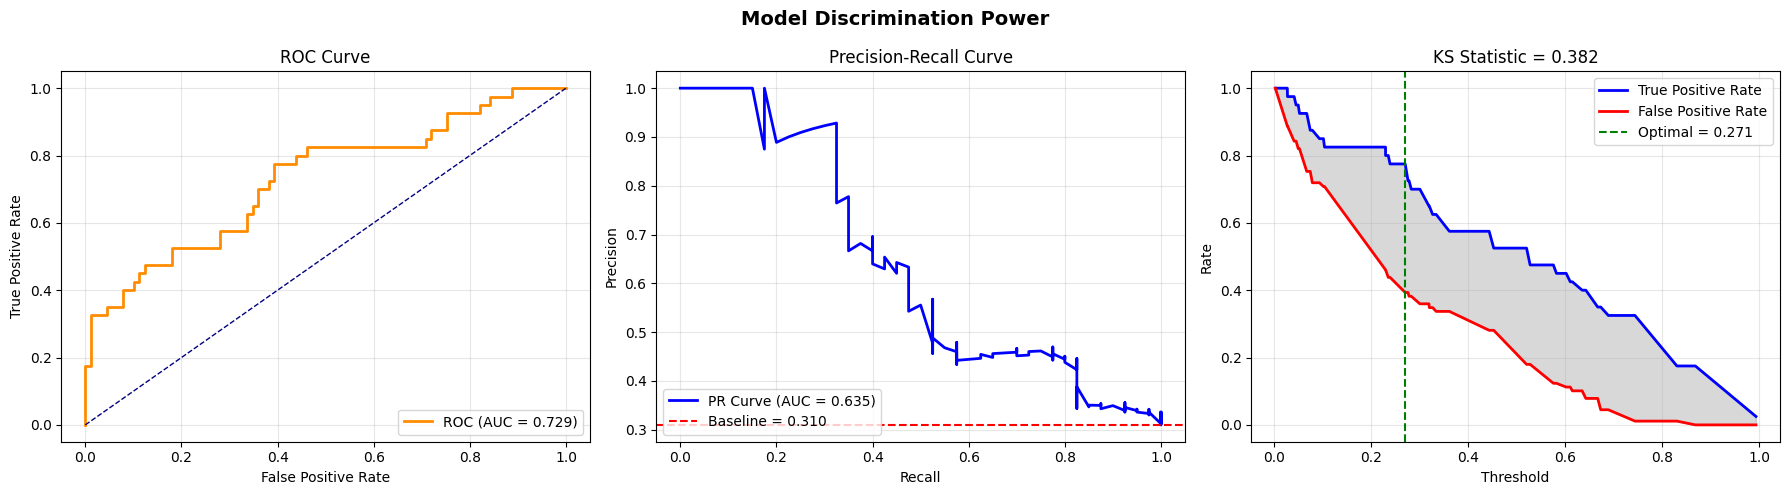

• ROC-AUC: 0.7295
• PR-AUC: 0.6348
• KS Statistic: 0.382 (MODERATE discrimination)
• Optimal Threshold: 0.271

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.879
Decile 10 mean prob: 0.020


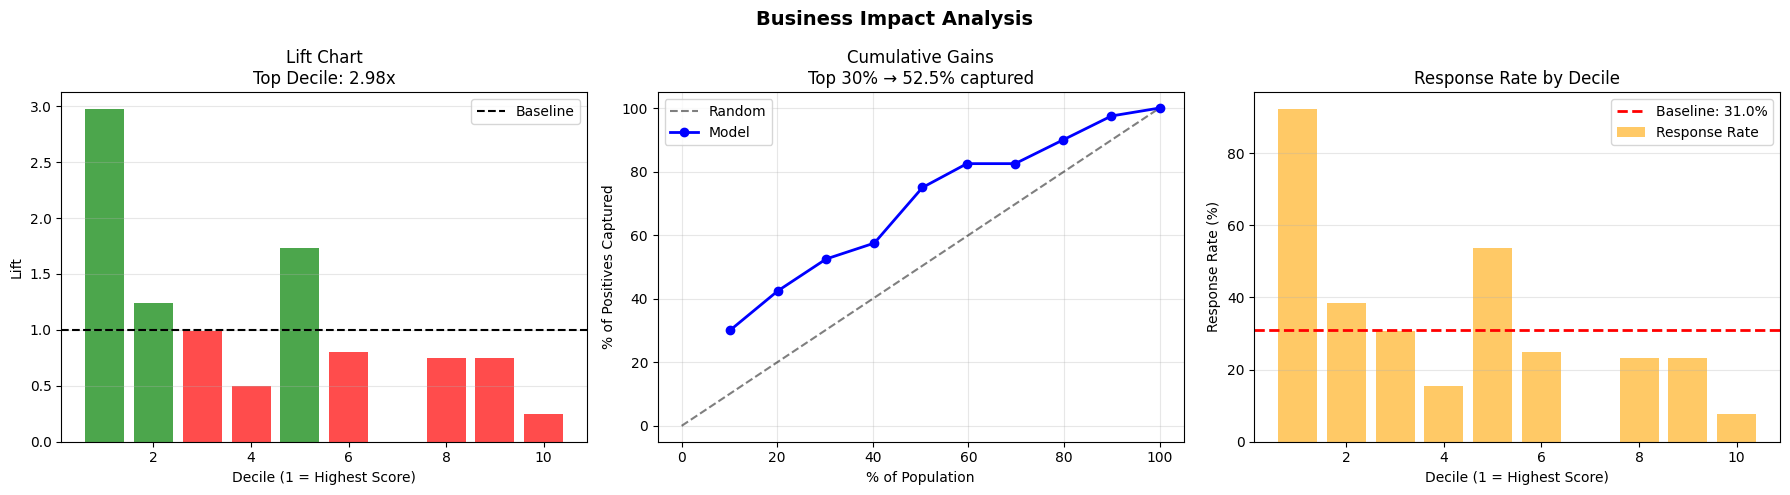

• Top Decile Lift: 0.25x
• Top 30% captures: 52.5% of positives
• Baseline response rate: 31.0%
• Top decile response: 92.3%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


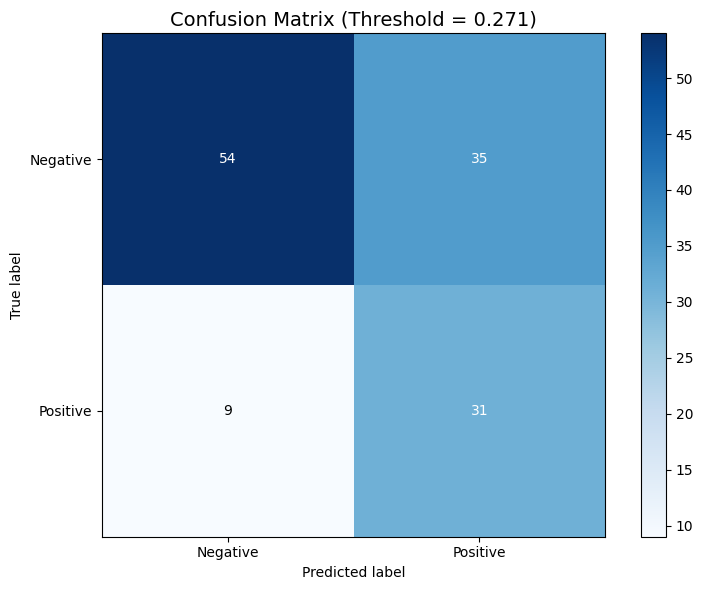

At threshold 0.271:
• Accuracy: 0.659
• Precision: 0.470
• Recall: 0.775
• F1-Score: 0.585
• True Positives: 31
• False Positives: 35
• True Negatives: 54
• False Negatives: 9

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.382 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.25x better than random
   Coverage: Top 30% → 52.5% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7295 (Excellent if >0.8)
   PR-AUC: 0.6348 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.271
   Precision at threshold: 0.470
   Recall at threshold: 0.775

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
178     quote_consistency_score    0.048457
167            is_quick_decider    0.030429
162               primary_brand    0.025734
150                   max_price    0.024935
95          primary_system_type    0.022987
153          unique_commercials    0.021610
55            latest_complexity    0.021145
133

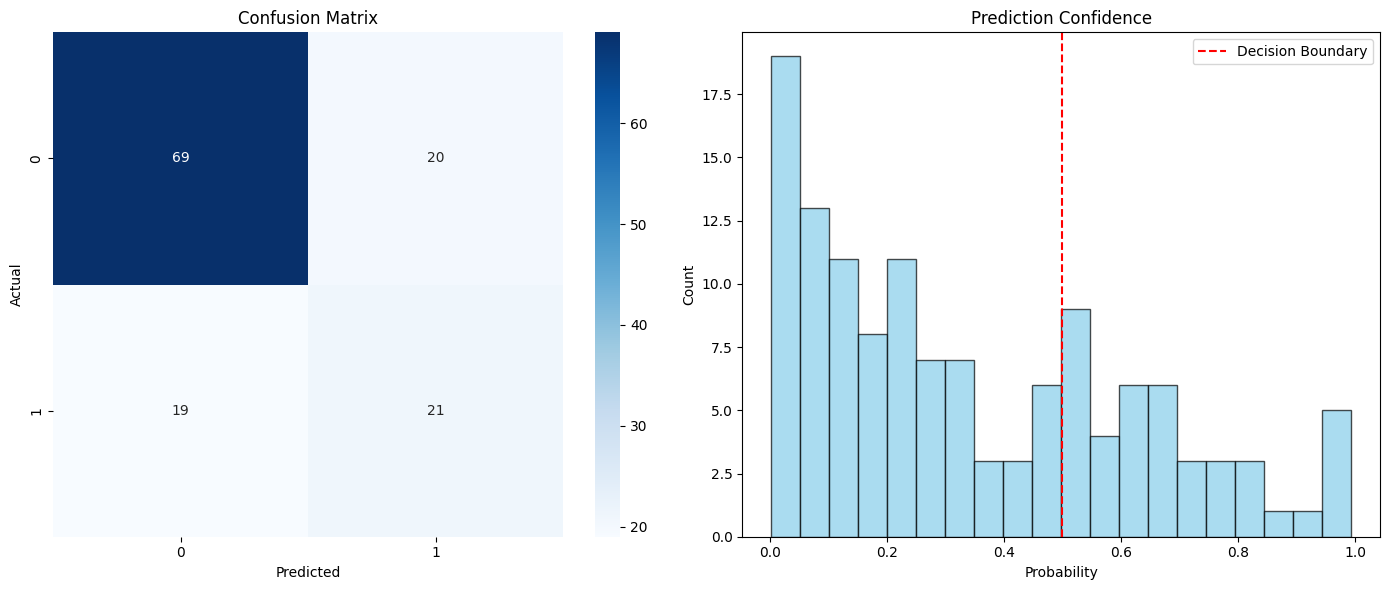

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])